In [ ]:
import os
from pathlib import Path

def _find_project_root():
    for cand in (Path.cwd(), *Path.cwd().parents):
        if (cand / 'data').is_dir() and (cand / 'notebooks').is_dir():
            return cand
    return Path.cwd()

os.chdir(os.environ.get('ML_IDS_ROOT') or _find_project_root())
print('Project root:', os.getcwd())

Project root: /home/user/22056253/ML-IDS


In [2]:
# ─────────────────────────────────────────────────────────────────────
# CELL 0 — Load raw CSVs (FULL dataset)
#
# Reads all 10 CIC-IDS-2018 CSV files from data/raw/ in full (~16 M rows).
# Every row of every class is kept — no subsampling — so the model trains
# and evaluates on the complete dataset.
# ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import os

data_folder = 'data/raw/'
all_files = sorted(f for f in os.listdir(data_folder) if f.endswith('.csv'))

dfs = []
for f in all_files:
    temp = pd.read_csv(os.path.join(data_folder, f), low_memory=False)
    dfs.append(temp)
    print(f'Loaded {f}: {temp.shape[0]} rows')

df = pd.concat(dfs, ignore_index=True)
print(f'\nTotal rows: {df.shape[0]}')
print(f'Total columns: {df.shape[1]}')

Loaded 02-14-2018.csv: 1048575 rows
Loaded 02-15-2018.csv: 1048575 rows
Loaded 02-16-2018.csv: 1048575 rows
Loaded 02-20-2018.csv: 7948748 rows
Loaded 02-21-2018.csv: 1048575 rows
Loaded 02-22-2018.csv: 1048575 rows
Loaded 02-23-2018.csv: 1048575 rows
Loaded 02-28-2018.csv: 613104 rows
Loaded 03-01-2018.csv: 331125 rows
Loaded 03-02-2018.csv: 1048575 rows

Total rows: 16233002
Total columns: 84


In [3]:
# ─────────────────────────────────────────────────────────────────────
# CELL 1 — Drop corrupted rows and non-predictive columns
#
# Removes rows where Label == "Label" — these are duplicate header lines
# that CICFlowMeter writes when it restarts mid-capture.
# Also drops identifier columns (Flow ID, Src IP, Dst IP, Src Port,
# Dst Port, Timestamp) that carry no predictive signal and would cause
# data leakage if retained (IPs and ports are flow-specific identifiers,
# not generalisable features).
# ─────────────────────────────────────────────────────────────────────
# Remove rows where Label is literally the word 'Label' (corrupted headers)
df = df[df['Label'] != 'Label']

# Drop non-predictive identifier columns
cols_to_drop = ['Flow ID', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port', 'Timestamp']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"Shape after dropping: {df.shape}")

Shape after dropping: (16232943, 78)


In [4]:
# ─────────────────────────────────────────────────────────────────────
# CELL 2 — Numeric conversion
#
# pd.to_numeric(errors="coerce") converts CICFlowMeter string values to
# float; any value that cannot be parsed (including "Infinity" strings)
# becomes NaN. Label is excluded from conversion via feature_cols.
# ─────────────────────────────────────────────────────────────────────
feature_cols = [c for c in df.columns if c != 'Label']
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')

print("Missing values after conversion:", df[feature_cols].isnull().sum().sum())

Missing values after conversion: 59721


In [5]:
# ─────────────────────────────────────────────────────────────────────
# CELL 3 — Replace infinite values with NaN
#
# Replaces np.inf and -np.inf produced by division-by-zero in the
# CICFlowMeter feature calculator (e.g. Flow Bytes/s when duration = 0).
# Imputation is intentionally deferred to after the train/val/test split
# so that imputation statistics (column medians) are derived from training
# data only — computing them on the full dataset would leak test information.
# ─────────────────────────────────────────────────────────────────────
# Replace infinite values with NaN.
# NaN imputation is deferred to after train/val/test split (see cell below)
# so that imputation statistics are derived from training data only.
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

print('Missing values after inf→NaN:', df[feature_cols].isnull().sum().sum())
print('Infinite values remaining:',    np.isinf(df[feature_cols].select_dtypes(include=np.number)).sum().sum())

Missing values after inf→NaN: 191520
Infinite values remaining: 0


In [6]:
# ─────────────────────────────────────────────────────────────────────
# CELL 4 — Label encoding
#
# Fits a sklearn LabelEncoder on the 15 traffic class strings and
# transforms them to integer indices 0–14.
# The encoder is saved to models/label_encoder.pkl so evaluation and
# inference code can map predictions back to human-readable class names.
# ─────────────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# df['Label'] was never modified between cell 4 and here — no need to reassign
y = le.fit_transform(df['Label'])

print("Classes found:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

Classes found:
  0 = Benign
  1 = Bot
  2 = Brute Force -Web
  3 = Brute Force -XSS
  4 = DDOS attack-HOIC
  5 = DDOS attack-LOIC-UDP
  6 = DDoS attacks-LOIC-HTTP
  7 = DoS attacks-GoldenEye
  8 = DoS attacks-Hulk
  9 = DoS attacks-SlowHTTPTest
  10 = DoS attacks-Slowloris
  11 = FTP-BruteForce
  12 = Infilteration
  13 = SQL Injection
  14 = SSH-Bruteforce


In [13]:
# ─────────────────────────────────────────────────────────────────────
# CELL 5 — Stratified train / val / test split and NaN imputation
#
# Splits the data 70 / 15 / 15 using stratified sampling so every class
# is represented proportionally in each split.
# NaN values are imputed with per-column medians fitted on X_train only.
# Fitting the imputer on the full dataset before splitting would constitute
# data leakage; applying training medians to val/test is the correct approach.
#
# ── Why 70 / 15 / 15 (and not 80/10/10, 60/20/20, or k-fold CV)? ──────
# A THREE-way split is used (not a two-way train/test) because two
# independent held-out sets are needed: the VALIDATION set (15%) is for
# threshold tuning and model selection, while the TEST set (15%) is kept
# completely untouched for final reporting. Reusing one set for both would
# leak tuning decisions into the reported metrics.
#
#   • 15% is already ~2.43 M rows per eval set — far past the point where
#     metrics stabilise, so spending 20% on evaluation buys nothing while
#     starving training. -> rules out 60/20/20.
#   • vs 80/10/10: 70% is still 11.4 M real training rows (ample), and 15%
#     gives the rarest class (~87 samples total) ~13 per split vs only ~9
#     at 10% — steadier rare-class recall. The extra training data from an
#     80% split is not needed at this scale.
#   • vs k-fold CV: at 16 M rows, CV means training every model k times on
#     11 M+ rows (very expensive); its variance-reduction benefit is
#     negligible when a single held-out test set is already 2.43 M rows.
#   • STRATIFIED (stratify=y) keeps the extreme class imbalance proportional
#     so all 15 classes appear in every split (rarest = 61 / 13 / 13).
#
# Mechanics: 30% is held out first (test_size=0.30 -> 70% train), then that
# 30% is halved (test_size=0.50) into 15% val + 15% test.
# random_state=42 makes the split reproducible.
# ─────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X = df[feature_cols].values

# 70% train / 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)

# split the 30% temp into 15% val / 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

# Impute NaN with column medians computed on X_train only — no leakage.
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

print(f'Train size: {X_train.shape[0]}')
print(f'Val size:   {X_val.shape[0]}')
print(f'Test size:  {X_test.shape[0]}')
print(f'NaN remaining — train:{np.isnan(X_train).sum()} val:{np.isnan(X_val).sum()} test:{np.isnan(X_test).sum()}')

Train size: 11363060
Val size:   2434941
Test size:  2434942
NaN remaining — train:0 val:0 test:0


In [8]:
# ─────────────────────────────────────────────────────────────────────
# CELL 6 — MinMaxScaler normalisation
#
# Scales all features to [0, 1] using MinMaxScaler fitted on X_train only.
# The same training statistics are applied to X_val and X_test to prevent
# leakage. [0, 1] scaling is required by the autoencoder (which uses Sigmoid
# output in the decoder) and also improves MLP convergence.
# Scaler and imputer are saved to models/ for use during inference.
# ─────────────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
import joblib

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)   # fit ONLY on training data
X_val   = scaler.transform(X_val)         # transform with train stats
X_test  = scaler.transform(X_test)        # transform with train stats

joblib.dump(scaler,   'models/scaler.pkl')
joblib.dump(imputer,  'models/imputer.pkl')
print("Scaler saved. X_train shape:", X_train.shape)
print("Imputer saved.")

Scaler saved. X_train shape: (11363060, 77)
Imputer saved.


In [9]:
# ─────────────────────────────────────────────────────────────────────
# CELL 7 — Save pre-SMOTE data, then apply SMOTE
#
# Saves X_train_original and y_train_original (pre-SMOTE) before oversampling.
# These are needed by the autoencoder (trained on real traffic only) and by
# mutual information feature selection (MI on synthetic SMOTE samples would
# overfit to the interpolated distribution).
# 
# SMOTE oversampling: creates synthetic minority-class samples by interpolating
# between k=3 nearest neighbours in feature space. A per-class cap limits each
# minority class to at most 10 % of the majority count to avoid extreme
# over-reliance on synthetic data for very rare classes.
# ─────────────────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np

# Save pre-SMOTE training data so feature selection can use real (non-synthetic) samples
os.makedirs('data/processed', exist_ok=True)
np.save('data/processed/X_train_original.npy', X_train)
np.save('data/processed/y_train_original.npy', y_train)
print("Original (pre-SMOTE) training data saved.")

# Cap oversampling: minority classes will not exceed 10% of the majority count.
counts = Counter(y_train)
majority_count = max(counts.values())
cap = majority_count // 10
sampling_strategy = {
    cls: min(cnt * 50, cap)
    for cls, cnt in counts.items()
    # exclude majority and any class whose current count already meets/exceeds the cap
    # (SMOTE can only add samples; a target < current count raises ValueError)
    if cnt < majority_count and cap > cnt
}

smote = SMOTE(random_state=42, k_neighbors=3, sampling_strategy=sampling_strategy)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {X_train.shape[0]}")
print(f"After SMOTE:  {X_train_bal.shape[0]}")
print(f"Class distribution after SMOTE: {Counter(y_train_bal)}")

Original (pre-SMOTE) training data saved.
Before SMOTE: 11363060
After SMOTE:  18412356
Class distribution after SMOTE: Counter({np.int64(0): 9439295, np.int64(6): 943929, np.int64(14): 943929, np.int64(12): 943929, np.int64(1): 943929, np.int64(8): 943929, np.int64(4): 943929, np.int64(7): 943929, np.int64(9): 943929, np.int64(11): 943929, np.int64(10): 384650, np.int64(5): 60550, np.int64(2): 21400, np.int64(3): 8050, np.int64(13): 3050})


In [11]:
# ─────────────────────────────────────────────────────────────────────
# CELL 8 — Save all processed arrays to disk
#
# Persists the SMOTE-balanced training set, val/test sets, and the label
# encoder to data/processed/ and models/.
# Downstream notebooks (feature_engineering, model_training, evaluation)
# load from these files rather than re-running the full preprocessing pipeline.
#
# Feature arrays are cast to float32 before saving. The features are already
# MinMax-scaled to [0, 1], so float32 (~7 decimal digits) is far more precision
# than the data carries — and it HALVES the on-disk footprint (X_train alone:
# 18.4 M x 77 = 11.3 GB as float64 -> 5.67 GB as float32), which matters under
# the 24 GB home quota. float32 is also the native dtype for the downstream
# torch autoencoder and is fine for the sklearn models.
# ─────────────────────────────────────────────────────────────────────
import os
import numpy as np
import joblib

os.makedirs('data/processed', exist_ok=True)

np.save('data/processed/X_train.npy', X_train_bal.astype(np.float32, copy=False))
np.save('data/processed/y_train.npy', y_train_bal)
np.save('data/processed/X_val.npy',   X_val.astype(np.float32, copy=False))
np.save('data/processed/y_val.npy',   y_val)
np.save('data/processed/X_test.npy',  X_test.astype(np.float32, copy=False))
np.save('data/processed/y_test.npy',  y_test)
joblib.dump(le, 'models/label_encoder.pkl')

# Canonical feature column order (stripped) so evaluation/explainability/inference
# resolve feature names from one source instead of re-deriving from raw headers.
import json
with open('models/feature_cols.json', 'w') as _f:
    json.dump([c.strip() for c in feature_cols], _f)

print('All saved successfully. Phase 2 preprocessing complete.')

All saved successfully. Phase 2 preprocessing complete.


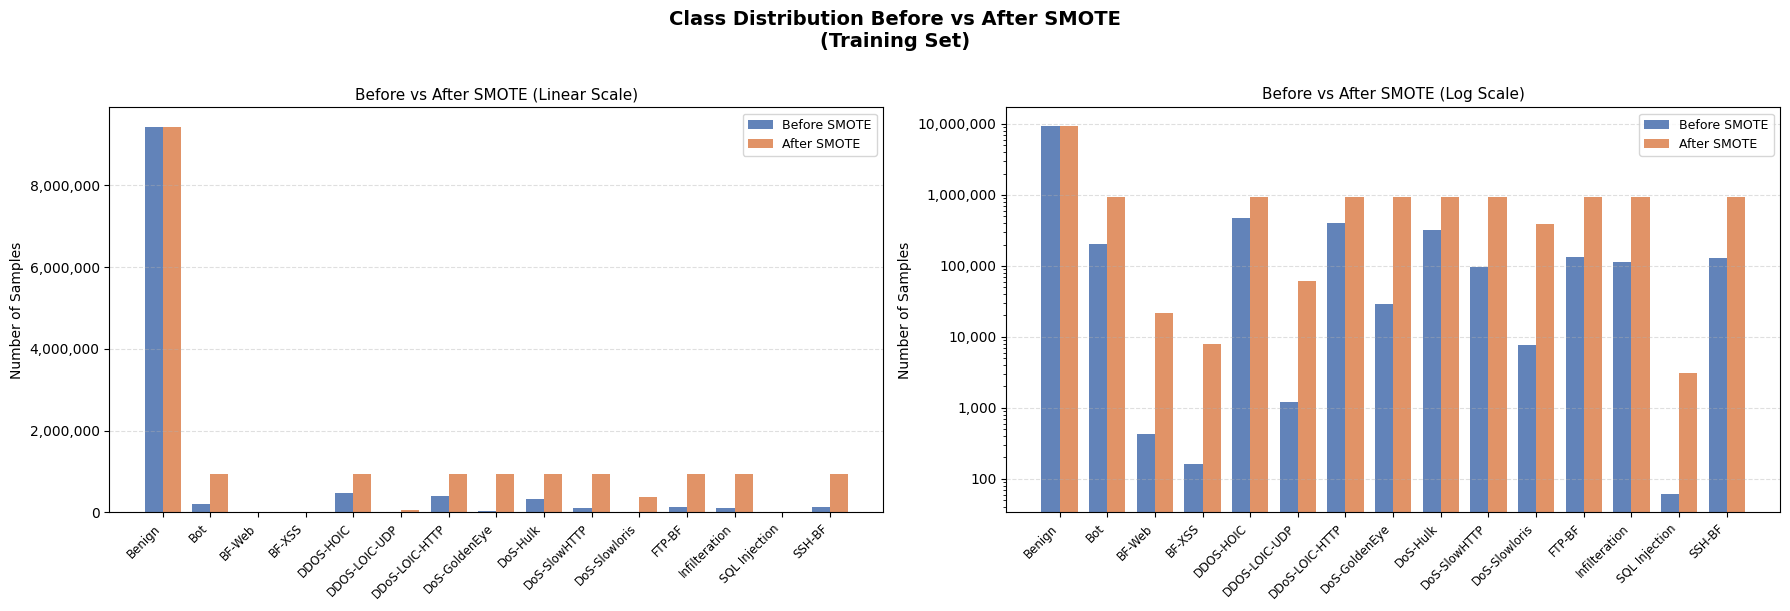

Saved → results/smote_distribution.png

Class                        Before        After      Change
──────────────────────────────────────────────────────────────
  Benign                  9,439,295    9,439,295           —
  Bot                       200,334      943,929    +743,595
  BF-Web                        428       21,400     +20,972
  BF-XSS                        161        8,050      +7,889
  DDOS-HOIC                 480,208      943,929    +463,721
  DDOS-LOIC-UDP               1,211       60,550     +59,339
  DDoS-LOIC-HTTP            403,334      943,929    +540,595
  DoS-GoldenEye              29,056      943,929    +914,873
  DoS-Hulk                  323,338      943,929    +620,591
  DoS-SlowHTTP               97,923      943,929    +846,006
  DoS-Slowloris               7,693      384,650    +376,957
  FTP-BF                    135,352      943,929    +808,577
  Infilteration             113,354      943,929    +830,575
  SQL Injection                  61        

In [12]:
# ─────────────────────────────────────────────────────────────────────
# CELL 9 — Class distribution before vs after SMOTE (visualisation)
#
# Loads y_train_original (pre-SMOTE) and y_train (post-SMOTE) from disk,
# then plots a side-by-side bar chart on linear and log scales so both
# the majority class (Benign) and the rare classes are legible in the
# same figure.  The plot is saved to results/smote_distribution.png.
# ─────────────────────────────────────────────────────────────────────
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter

y_orig  = np.load('data/processed/y_train_original.npy')
y_smote = np.load('data/processed/y_train.npy')
le      = joblib.load('models/label_encoder.pkl')

classes = le.classes_
n_cls   = len(classes)
before  = Counter(y_orig)
after   = Counter(y_smote)
counts_before = np.array([before[i] for i in range(n_cls)])
counts_after  = np.array([after[i]  for i in range(n_cls)])

short = ['Benign', 'Bot', 'BF-Web', 'BF-XSS', 'DDOS-HOIC', 'DDOS-LOIC-UDP',
         'DDoS-LOIC-HTTP', 'DoS-GoldenEye', 'DoS-Hulk', 'DoS-SlowHTTP',
         'DoS-Slowloris', 'FTP-BF', 'Infilteration', 'SQL Injection', 'SSH-BF']

x = np.arange(n_cls); width = 0.38; colors = ('#4C72B0', '#DD8452')
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Class Distribution Before vs After SMOTE\n(Training Set)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, yscale, title_sfx in zip(axes, ['linear', 'log'], ['(Linear Scale)', '(Log Scale)']):
    ax.bar(x - width/2, counts_before, width, label='Before SMOTE', color=colors[0], alpha=0.88)
    ax.bar(x + width/2, counts_after,  width, label='After SMOTE',  color=colors[1], alpha=0.88)
    ax.set_yscale(yscale)
    ax.set_xticks(x)
    ax.set_xticklabels(short, rotation=45, ha='right', fontsize=8.5)
    ax.set_ylabel('Number of Samples', fontsize=10)
    ax.set_title(f'Before vs After SMOTE {title_sfx}', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

plt.tight_layout()
out = 'results/smote_distribution.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

print(f"\n{'Class':<22} {'Before':>12} {'After':>12}  {'Change':>10}")
print('─' * 62)
for i, sh in enumerate(short):
    b, a = counts_before[i], counts_after[i]
    chg = f'+{a-b:,}' if a > b else '—'
    print(f'  {sh:<20} {b:>12,} {a:>12,}  {chg:>10}')
print('─' * 62)
print(f'  {"TOTAL":<20} {counts_before.sum():>12,} {counts_after.sum():>12,}')